# Exploratory Data Analysis

## Objective

The objective of this exploratory analysis is to investigate the relationships
and underlying structure of the California Housing dataset before building
regression models.

The analysis is guided by the following questions:

1. Which features show the strongest relationship with the target variable,
   `median_house_value`?

2. Are there strong relationships between the predictor variables that may
   indicate redundancy or multicollinearity?

3. Are the relationships between important features and the target
   approximately linear, or do they show nonlinear patterns?

4. Does geographic information, represented by `latitude` and `longitude`,
   appear to be associated with housing prices?

5. Are there extreme observations that could have a significant influence
   on regression models?

6. Do missing values appear to be distributed randomly, or are they
   associated with particular characteristics of the observations?

The findings from this analysis will be used to formulate hypotheses and
design experiments for investigating feature selection, feature scaling,
and model complexity in subsequent stages of the project.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data/Raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Assign Column Types

In [4]:
numerical_features = df.select_dtypes(include=["int64", 'float64']).columns.tolist()
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [5]:
categorical_features = df.select_dtypes(include=['str']).columns.tolist()
categorical_features

['ocean_proximity']

In [6]:
# Droping Target Variable from Numerical Features
# Target_variable -> median_house_value

numerical_features.remove('median_house_value')

### Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


In [7]:
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [8]:
df['longitude'].describe()

count    20640.000000
mean      -119.569704
std          2.003532
min       -124.350000
25%       -121.800000
50%       -118.490000
75%       -118.010000
max       -114.310000
Name: longitude, dtype: float64

<Axes: xlabel='longitude', ylabel='Density'>

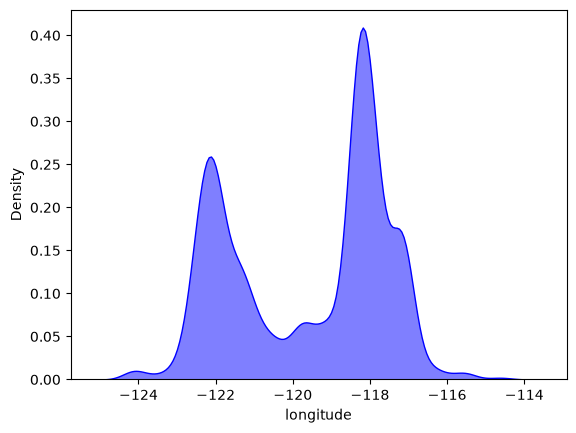

In [9]:
sns.kdeplot(df["longitude"], fill=True, color="blue", alpha=0.5)  # There is Bimodal Distribution in Data

<Axes: ylabel='Frequency'>

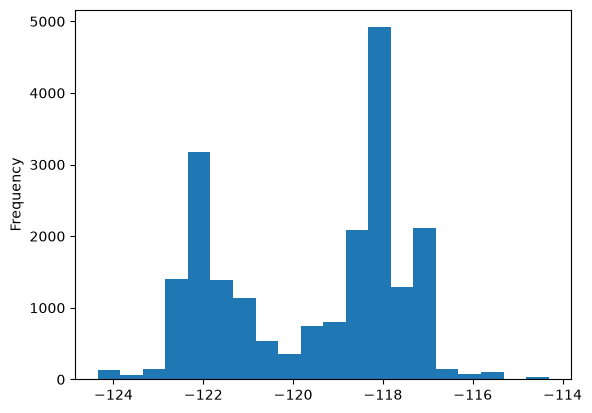

In [10]:
df['longitude'].plot(kind="hist", bins=20)

In [11]:
df['longitude'].skew()

np.float64(-0.2978012079524363)

<Axes: >

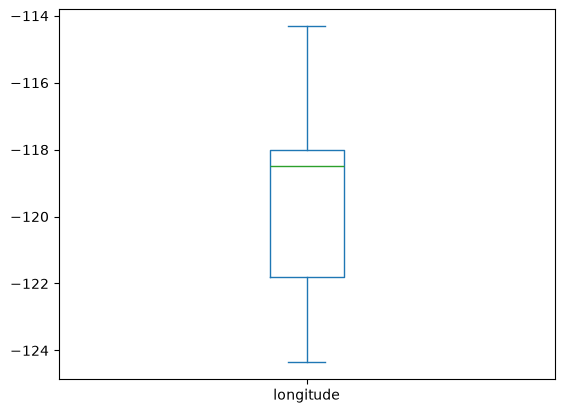

In [12]:
# Detecting Outliers 
df['longitude'].plot(kind='box')
# There are no Such Outliers in Data

In [13]:
# CONCLUSION
# 1. There is bimodal Distribution in Data
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data


In [14]:
df['latitude'].describe()

count    20640.000000
mean        35.631861
std          2.135952
min         32.540000
25%         33.930000
50%         34.260000
75%         37.710000
max         41.950000
Name: latitude, dtype: float64

<Axes: xlabel='latitude', ylabel='Density'>

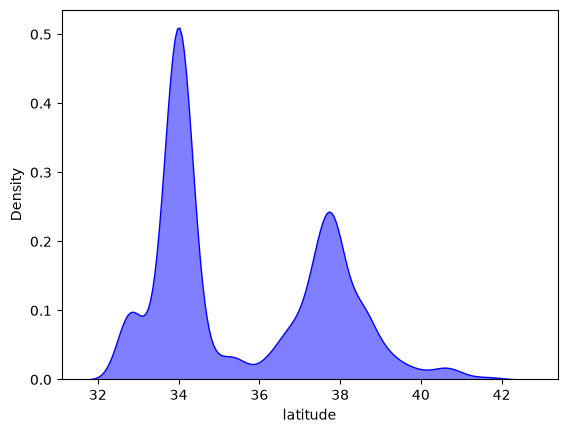

In [15]:
sns.kdeplot(df["latitude"], fill=True, color="blue", alpha=0.5) #There is a bimodal Distribution 

<Axes: ylabel='Frequency'>

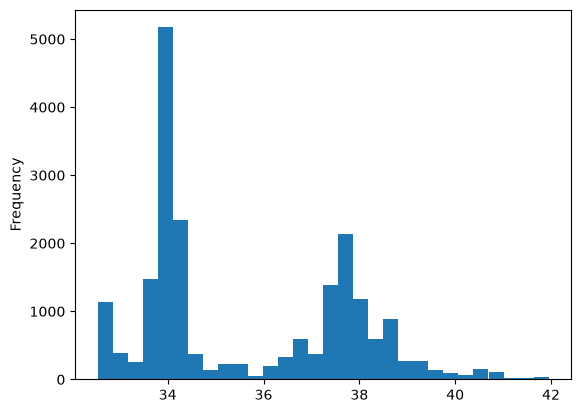

In [16]:
df['latitude'].plot(kind='hist',bins=30)

<Axes: >

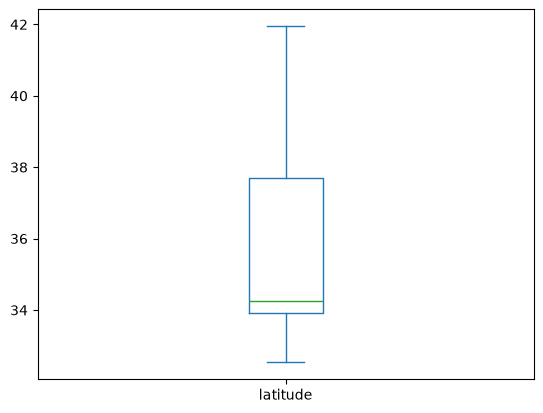

In [17]:
# Detecting Outliers 
df['latitude'].plot(kind='box')
#There are no such Outliers in the Data


In [18]:
df['latitude'].skew()

np.float64(0.4659530037099799)

In [19]:
# CONCLUSION
# 1. There is bimodal Distribution in Data
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data 
# 4. Data distribution is approximately symmetric with a slight positive (right) skew.

In [20]:
df['housing_median_age'].describe()

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

<Axes: xlabel='housing_median_age', ylabel='Density'>

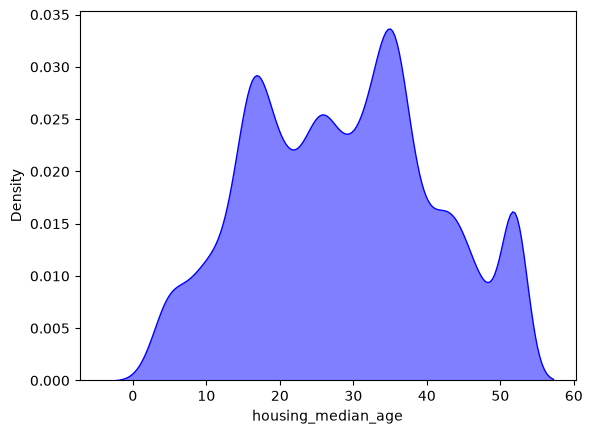

In [21]:
sns.kdeplot(df['housing_median_age'], fill=True, color='Blue',alpha=0.5)

<Axes: ylabel='Frequency'>

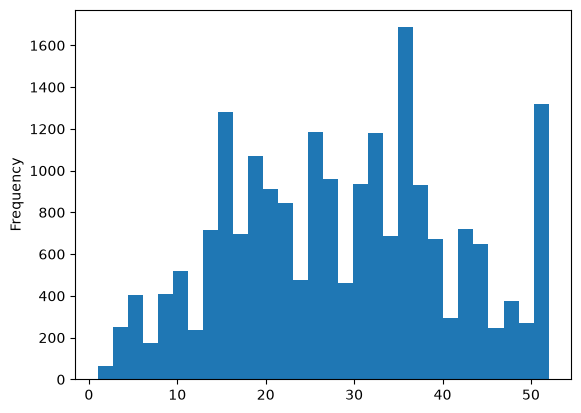

In [22]:
df['housing_median_age'].plot(kind='hist', bins=30)

In [23]:
df['housing_median_age'].skew()

np.float64(0.06033063759913685)

<Axes: >

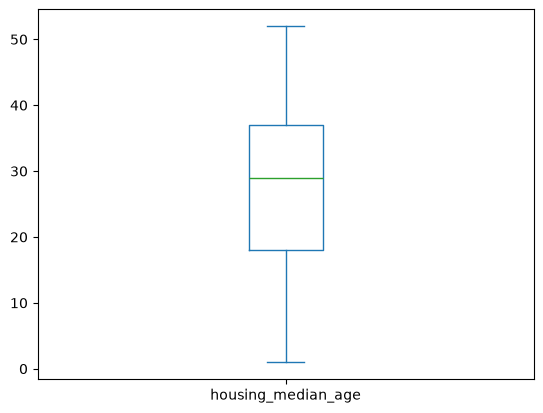

In [24]:
df['housing_median_age'].plot(kind='box')

In [25]:
#In conclusion, 
# 1. this is a multimodal distribution spanning roughly 0 to 55 years, 
#    featuring a prominent peak at 35 years and a sharp artificial cap near 52 years.
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data


In [26]:
df['total_rooms'].describe()

count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

<Axes: xlabel='total_rooms', ylabel='Density'>

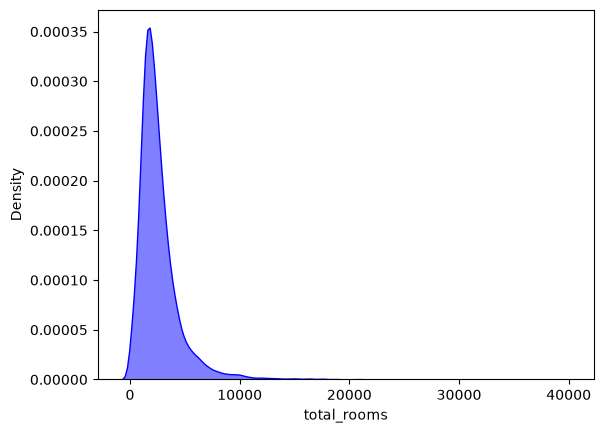

In [27]:
sns.kdeplot(df['total_rooms'], fill=True, color="blue", alpha=0.5) 

<Axes: ylabel='Frequency'>

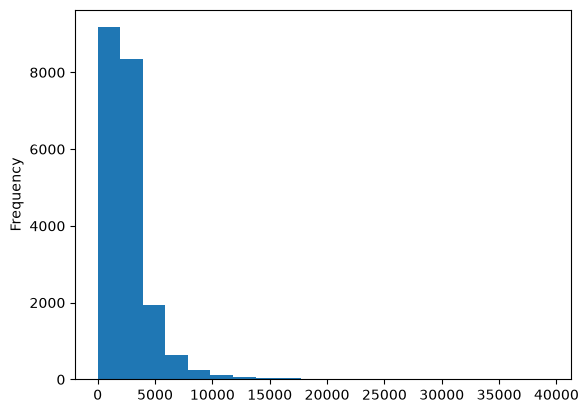

In [28]:
df['total_rooms'].plot(kind='hist', bins=20)

In [29]:
df['total_rooms'].skew() #Total_rooms Data is highly Right Skewwed

np.float64(4.147343450632158)

<Axes: >

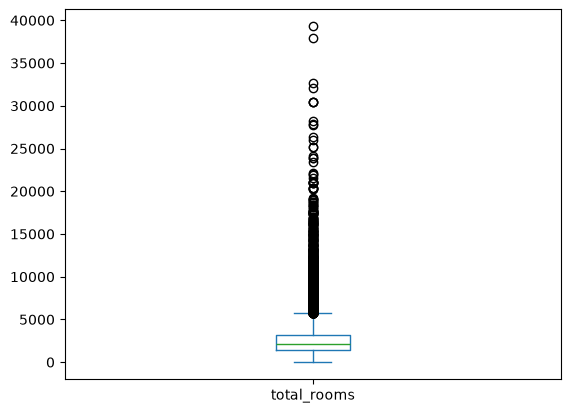

In [30]:
df['total_rooms'].plot(kind='box')

In [31]:
import pandas as pd

# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['total_rooms'].quantile(0.25)
Q3 = df['total_rooms'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['total_rooms'] < lower_bound) | (df['total_rooms'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in total_rooms: {total_outliers}")


Lower Bound: -1102.625
Upper Bound: 5698.375
Total outliers in total_rooms: 1287


In [32]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1287 ouliers in total_rooms Column
# 3. There are no missiong values there

In [33]:
df['total_bedrooms'].describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [34]:
df['total_bedrooms'].isnull().sum()
#There are total 207 missing values

np.int64(207)

<Axes: xlabel='total_bedrooms', ylabel='Density'>

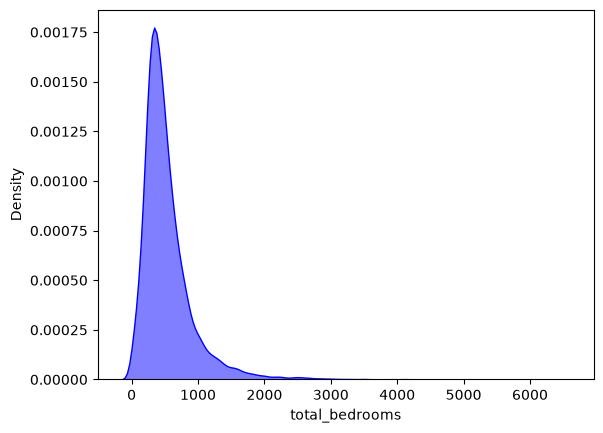

In [35]:
sns.kdeplot(df['total_bedrooms'], fill=True, color='Blue', alpha=0.5)

In [36]:
df['total_bedrooms'].skew() #Highly Right Skewed

np.float64(3.459546331523342)

<Axes: >

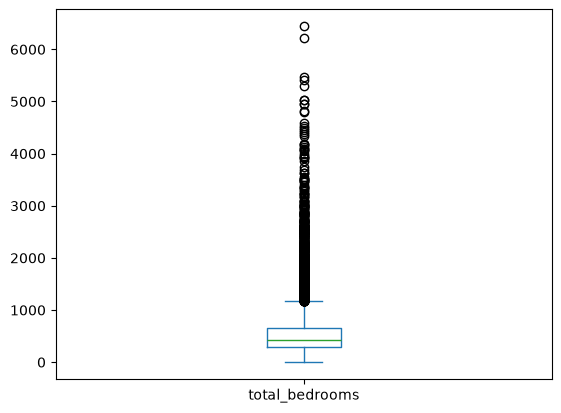

In [37]:
df['total_bedrooms'].plot(kind="box")

In [38]:
# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['total_bedrooms'].quantile(0.25)
Q3 = df['total_bedrooms'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['total_bedrooms'] < lower_bound) | (df['total_bedrooms'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in total_bedrooms: {total_outliers}")

Lower Bound: -230.5
Upper Bound: 1173.5
Total outliers in total_bedrooms: 1271


In [39]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1271 ouliers in total_bedrooms Column
# 3. There are a total 207 missiong values 

In [40]:
df['population'].describe()

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: population, dtype: float64

<Axes: xlabel='population', ylabel='Density'>

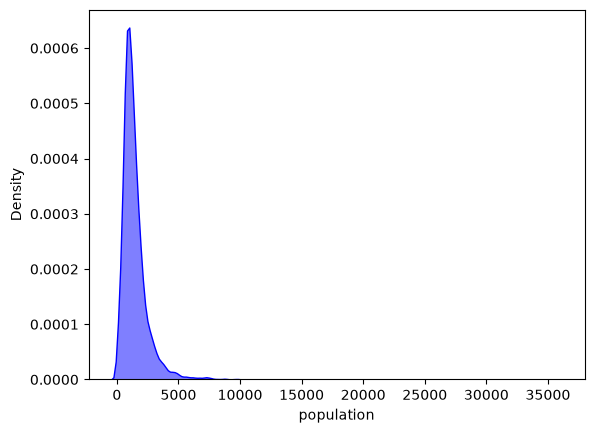

In [41]:
sns.kdeplot(df['population'], fill=True, alpha=0.5, color="Blue")

In [42]:
df['population'].skew() #Highly Right skewed

np.float64(4.935858226727124)

<Axes: >

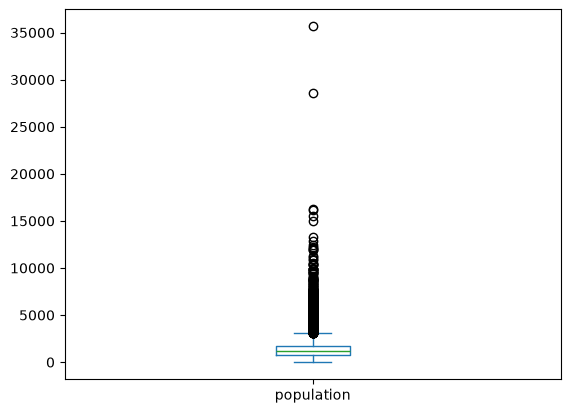

In [43]:
df['population'].plot(kind='box')

In [44]:
# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['population'].quantile(0.25)
Q3 = df['population'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['population'] < lower_bound) | (df['population'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in population: {total_outliers}")

Lower Bound: -620.0
Upper Bound: 3132.0
Total outliers in population: 1196


In [45]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1196 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [46]:
df['households'].describe()

count    20640.000000
mean       499.539680
std        382.329753
min          1.000000
25%        280.000000
50%        409.000000
75%        605.000000
max       6082.000000
Name: households, dtype: float64

<Axes: xlabel='households', ylabel='Density'>

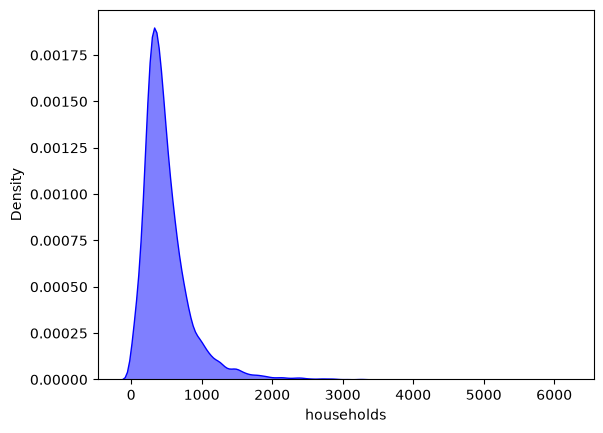

In [47]:
sns.kdeplot(df['households'], fill=True, alpha=0.5, color="Blue")

In [48]:
df['households'].skew() #Highly Right Skewed

np.float64(3.4104377116671474)

<Axes: >

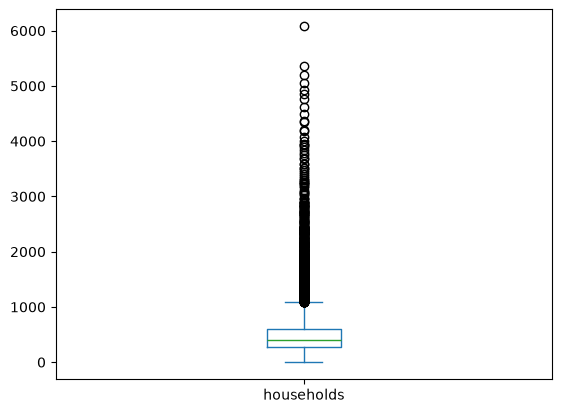

In [49]:
df['households'].plot(kind='box')

In [50]:
Q1 = df['households'].quantile(0.25)
Q3 = df['households'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['households'] < lower_bound) | (df['households'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in households: {total_outliers}")

Lower Bound: -207.5
Upper Bound: 1092.5
Total outliers in households: 1220


In [51]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1220 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [52]:
df['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

<Axes: xlabel='median_income', ylabel='Density'>

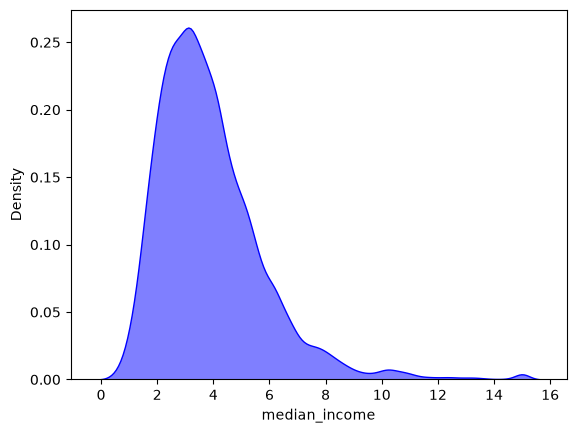

In [53]:
sns.kdeplot(df['median_income'], fill=True, alpha=0.5, color="Blue")

In [54]:
df['median_income'].skew() #right skewed

np.float64(1.6466567021344465)

<Axes: >

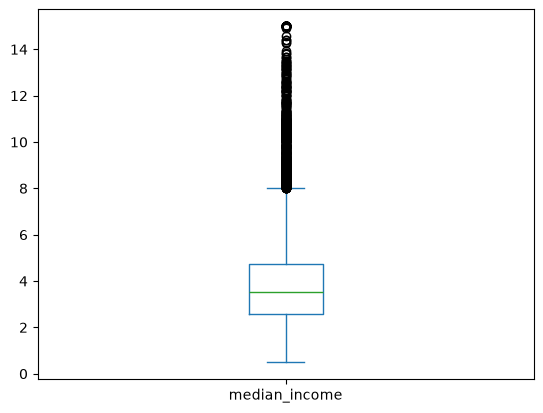

In [55]:
df['median_income'].plot(kind='box')

In [56]:
Q1 = df['median_income'].quantile(0.25)
Q3 = df['median_income'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['median_income'] < lower_bound) | (df['median_income'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in median_income: {total_outliers}")

Lower Bound: -0.7063750000000004
Upper Bound: 8.013024999999999
Total outliers in median_income: 681


In [57]:
#Conclusion 
# 1. Data is right skewed
# 2. There are total 681 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [58]:
df['ocean_proximity'].describe()

count         20640
unique            5
top       <1H OCEAN
freq           9136
Name: ocean_proximity, dtype: object

<Axes: xlabel='ocean_proximity', ylabel='Count'>

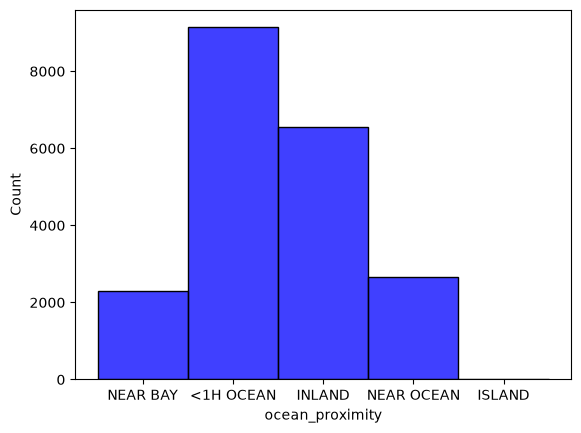

In [59]:
sns.histplot(df['ocean_proximity'], fill=True, color="blue")

In [60]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: >

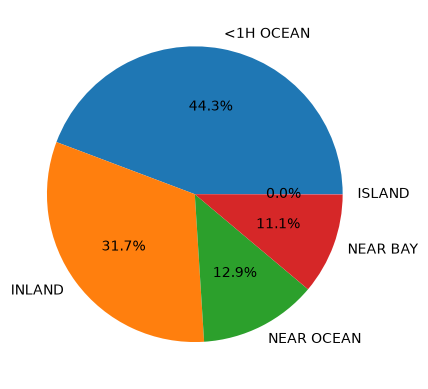

In [61]:
df['ocean_proximity'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 1. Correlation Analysis

Correlation analysis is used to investigate the strength and direction of
linear relationships between numerical variables.

The analysis has two main objectives:

- Identify numerical features that have a strong relationship with
  `median_house_value`.
- Identify relationships between predictor variables that may indicate
  redundancy or multicollinearity.

Correlation alone does not establish causation or determine whether a
feature will improve model performance. Therefore, the results will be
treated as exploratory evidence and investigated further through modeling
experiments.

In [62]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## 1.1 Predictor Variables Relationships

Strong correlations between predictor variables may indicate that some
features contain overlapping information.

This is relevant to the research question because redundant or highly
correlated features may affect coefficient stability and may influence
the behavior of feature selection and regularization methods.

In [ ]:
#correlation matrix for numerical variables.

correlation_matrix = df[numerical_features].corr(method='pearson')
correlation_matrix


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000


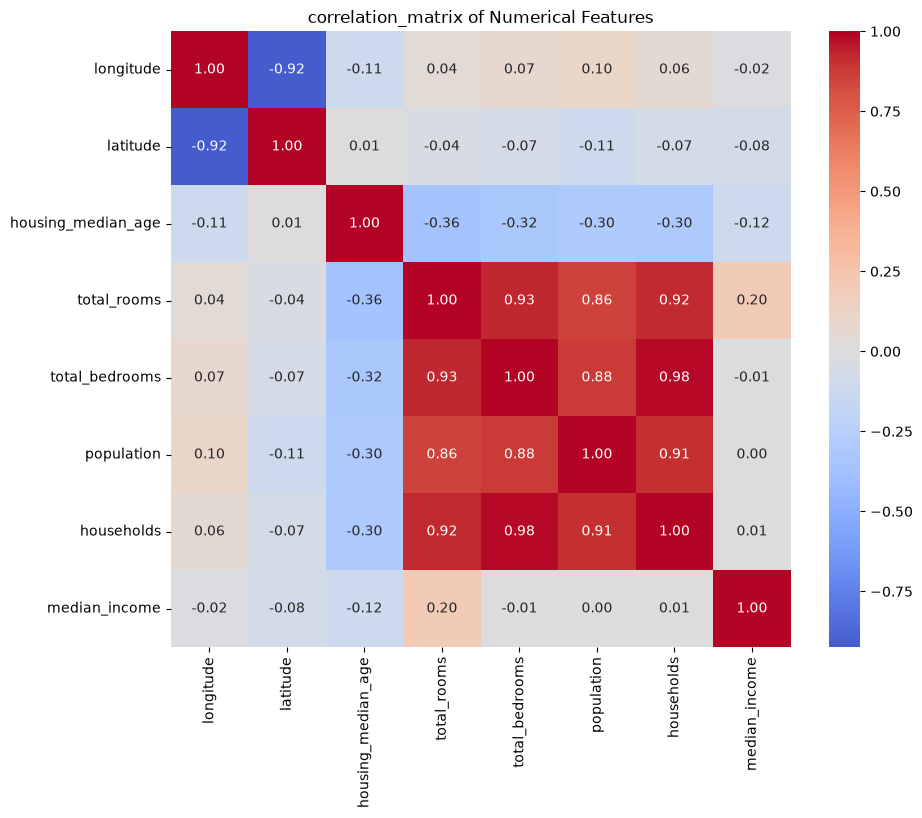

In [67]:
#Visualizing the Correlation matrix
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('correlation_matrix of Numerical Features')
plt.show()

## 1.2 Correlation with Target

To identify the numerical variables that have the strongest linear
association with `median_house_value`, we examine the correlation of each
numerical feature with the target variable.

In [ ]:
#Correlation of all Numerical Features with Target feature
df[numerical_features].corrwith(df['median_house_value']).sort_values(ascending=False)

median_income         0.688075
latitude              0.144160
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
longitude             0.045967
population            0.024650
dtype: float64

In [ ]:
#absolute correlation
df[numerical_features].corrwith(df['median_house_value']).abs().sort_values(ascending=False)

median_income         0.688075
latitude              0.144160
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
longitude             0.045967
population            0.024650
dtype: float64

In [73]:
target_corr = df[numerical_features].corrwith(df['median_house_value']).sort_values(ascending=False)

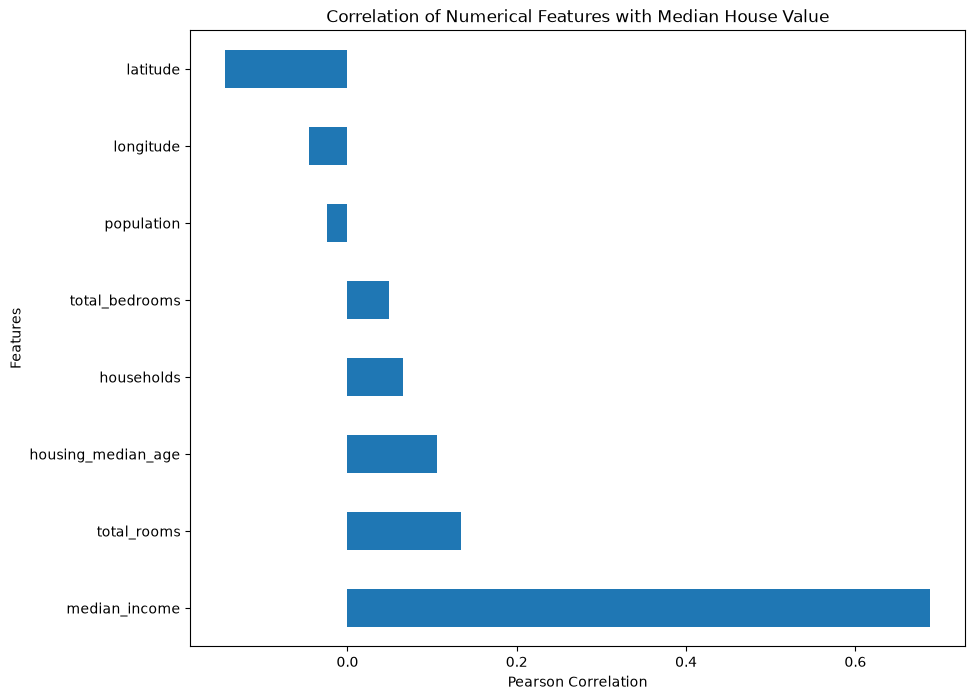

In [77]:
#Visualize feature-target correlations
plt.figure  (figsize=(10,8))

target_corr.plot(kind='barh')

plt.xlabel('Pearson Correlation')
plt.ylabel("Features")
plt.title("Correlation of Numerical Features with Median House Value")

plt.show()


## Correlation Analysis

Key Findings

The correlation analysis reveals several important patterns in the
California Housing dataset.

1. `median_income` has the strongest linear association with
   `median_house_value` (r ≈ 0.688), indicating that higher-income
   neighborhoods tend to have higher median house values.

2. The size-related variables `total_rooms`, `total_bedrooms`,
   `population`, and `households` exhibit strong correlations with
   one another. In particular, `total_bedrooms` and `households`
   have a correlation of approximately 0.98, suggesting substantial
   redundancy among these predictors.

3. `latitude` and `longitude` have a very strong negative correlation
   (r ≈ -0.925), reflecting the geographic structure of the dataset.

4. Several features have relatively weak linear correlations with the
   target. However, weak Pearson correlation does not necessarily imply
   low predictive value because nonlinear relationships and interactions
   may exist.

5. The correlation results therefore motivate further investigation of
   feature redundancy, geographic patterns, and nonlinear relationships
   before selecting features or choosing a model.

# 2. Deeper Feature-Target Relationships

Correlation analysis provides a numerical measure of linear association
between the features and `median_house_value`. However, correlation alone
cannot reveal nonlinear patterns, clusters, saturation effects, or the
influence of extreme observations.

In this section, we investigate the relationships between important
predictor variables and the target variable, `median_house_value`, using
visual and grouped analysis.

The main questions are:

1. Are the relationships between important features and house value
   approximately linear?

2. Do some features exhibit nonlinear or saturation effects?

3. Are there distinct groups or patterns that are not captured by
   Pearson correlation?

4. Are extreme observations strongly influencing the observed
   relationships?

The findings will help determine whether a simple Linear Regression model
is likely to be sufficient or whether more complex relationships should
be investigated.

## 2.1 Median Income vs Median House Value

`median_income` has the strongest linear correlation with
`median_house_value` among the numerical predictors.

We investigate this relationship visually to determine whether the
association is approximately linear or whether nonlinear patterns are
present.

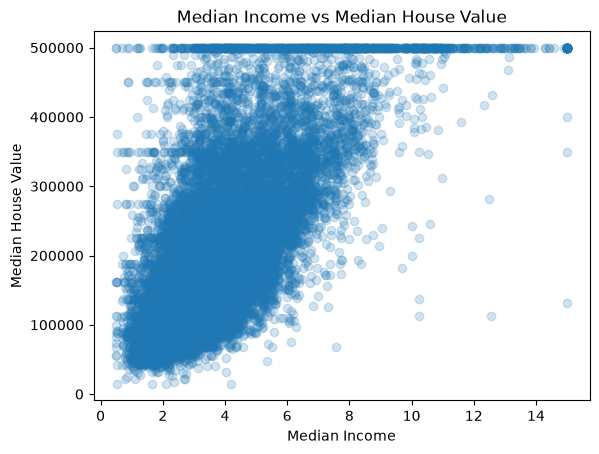

In [81]:
plt.scatter(df['median_income'], df['median_house_value'],alpha=0.2)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

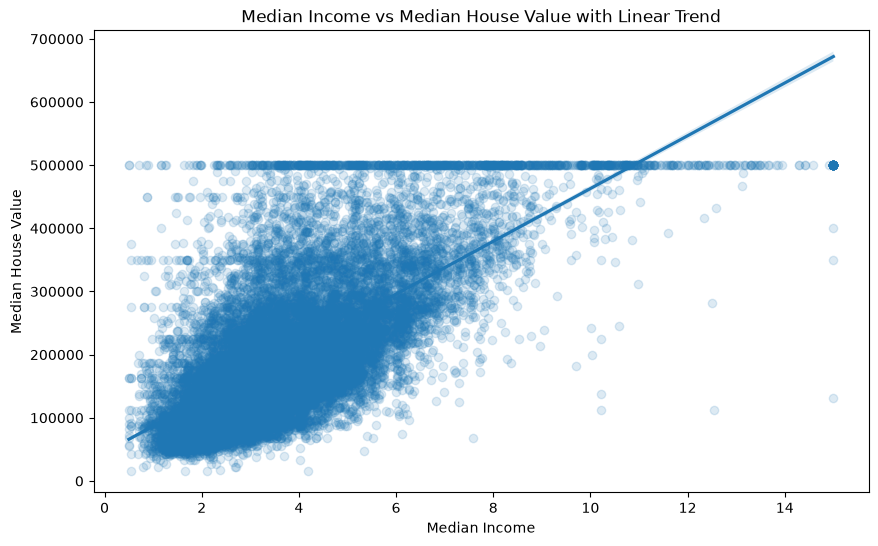

In [ ]:
#Adding a regression line
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="median_income",
    y="median_house_value",
    scatter_kws={"alpha": 0.15},
    line_kws={}
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value with Linear Trend")

plt.show()

In [ ]:
# dividing median income into 10 bins of equal size
income_bins = pd.qcut(
    df["median_income"],
    q=10,
    duplicates="drop"
)  

# applying mean median std and count function on those 10 bins
income_analysis = (
    df.groupby(income_bins, observed=True)["median_house_value"]
      .agg(["mean", "median", "std", "count"])
) 

income_analysis

,mean,median,std,count
median_income,,,,
"(0.499, 1.904]",110179.676186,90600.0,71543.753938,2066
"(1.904, 2.352]",126633.772287,112400.0,68054.372586,2064
"(2.352, 2.74]",147723.127000,136700.0,72603.622851,2063
"(2.74, 3.141]",166314.465667,152050.0,78772.664667,2068
"(3.141, 3.535]",186252.415736,167800.0,85684.380428,2059
"(3.535, 3.967]",201508.156977,180200.0,89972.306599,2064
"(3.967, 4.438]",220746.880929,198400.0,94082.164829,2066
"(4.438, 5.11]",239329.370999,222050.0,89210.896999,2062
"(5.11, 6.159]",279994.330426,261100.0,92968.533327,2064


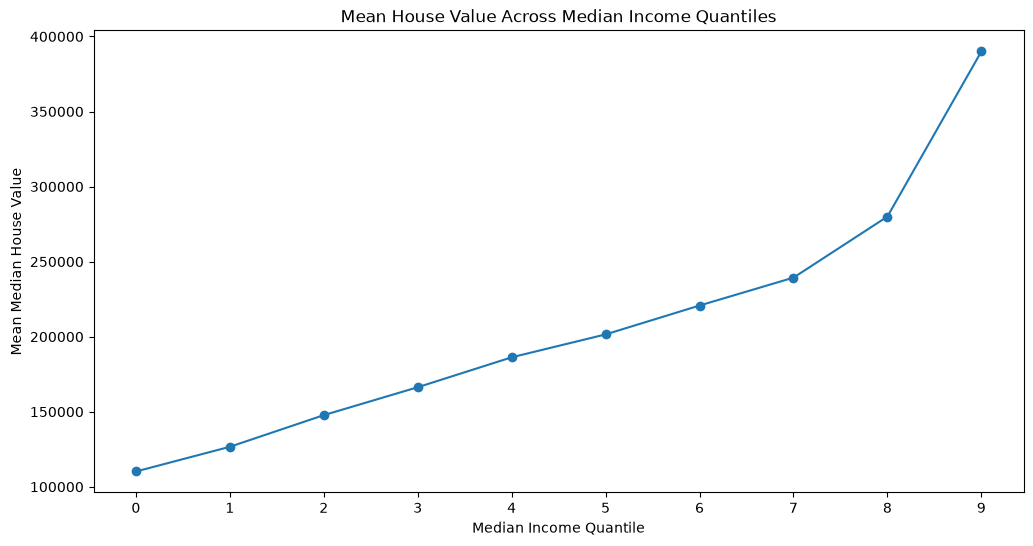

In [85]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(len(income_analysis)),
    income_analysis["mean"],
    marker="o"
)

plt.xlabel("Median Income Quantile")
plt.ylabel("Mean Median House Value")
plt.title("Mean House Value Across Median Income Quantiles")
plt.xticks(range(len(income_analysis)))

plt.show()

### 2.2 housing_median_age VS median_house_value

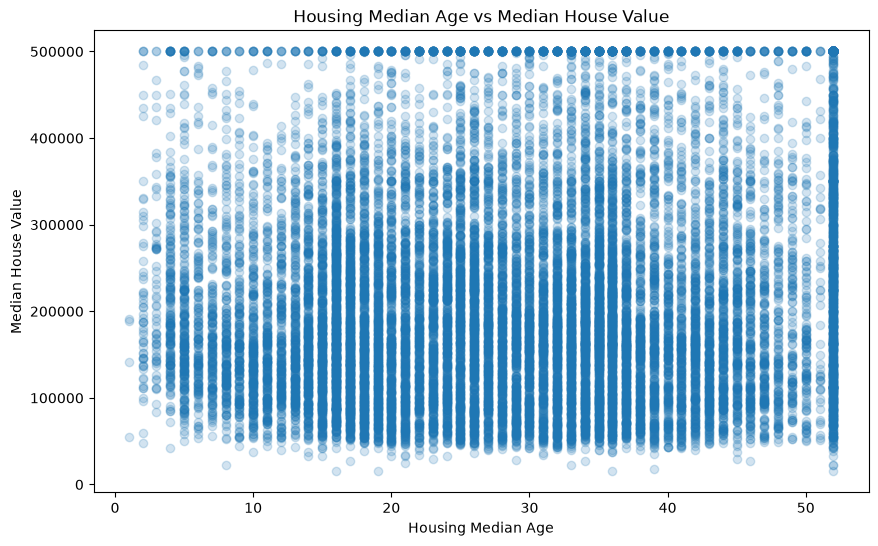

In [86]:
plt.figure(figsize=(10,6))

plt.scatter(df["housing_median_age"],df['median_house_value'], alpha=0.2)

plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Housing Median Age vs Median House Value")
plt.show()


### 2.3 total_rooms vs median_house_value

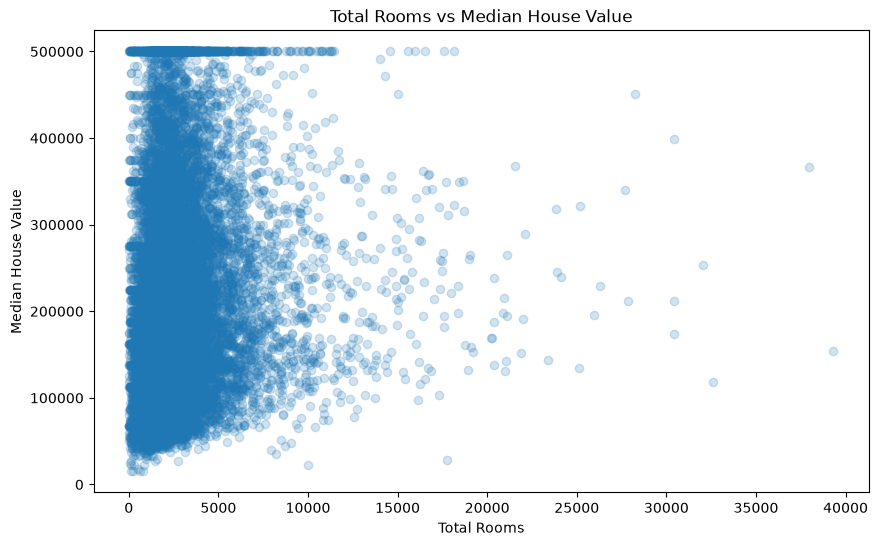

In [87]:
plt.figure(figsize=(10, 6))

plt.scatter(df["total_rooms"], df["median_house_value"], alpha=0.2)

plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.title("Total Rooms vs Median House Value")

plt.show()

### 2.4 Investigate weakly correlated features

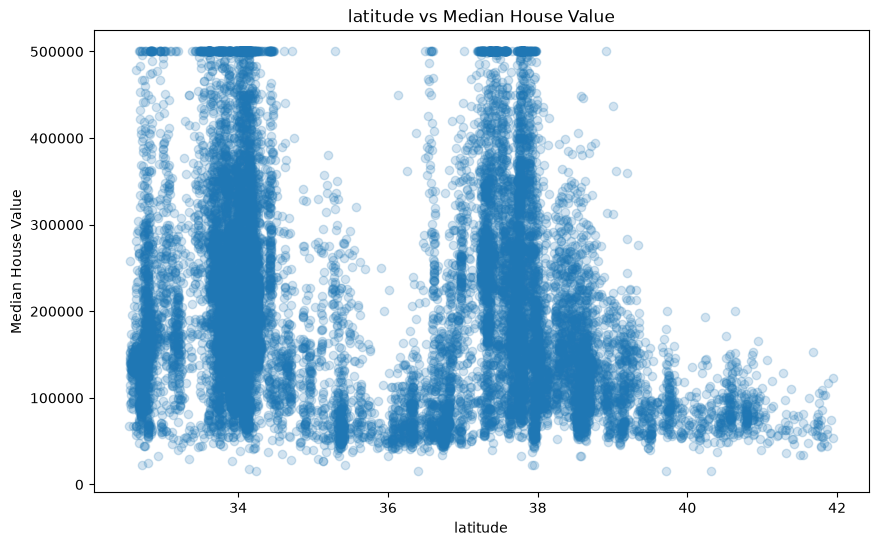

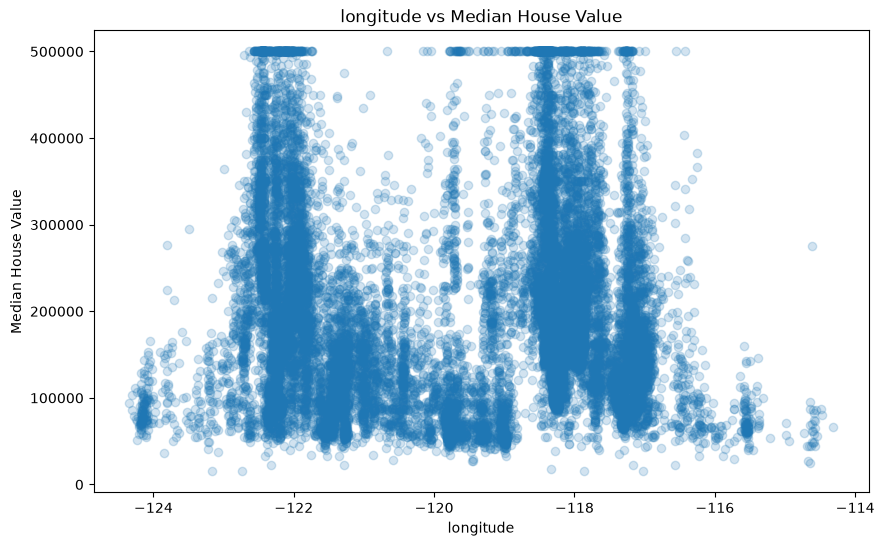

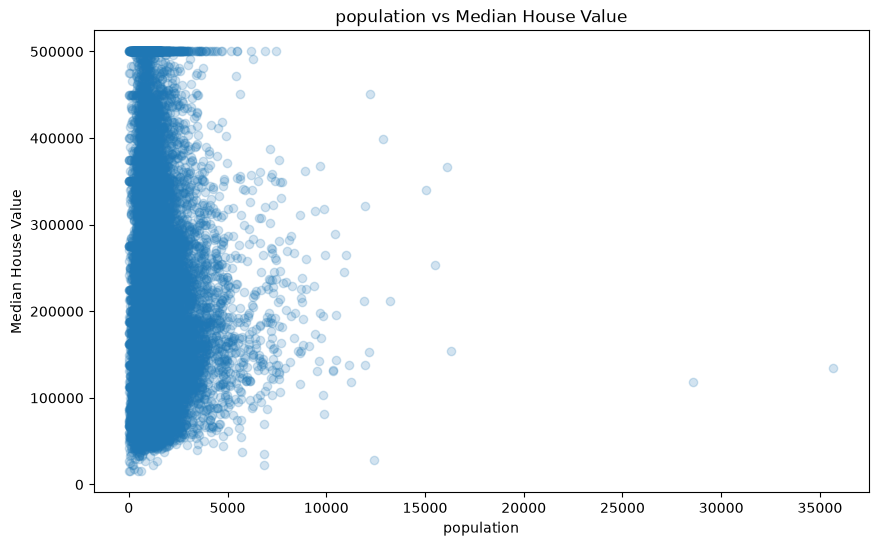

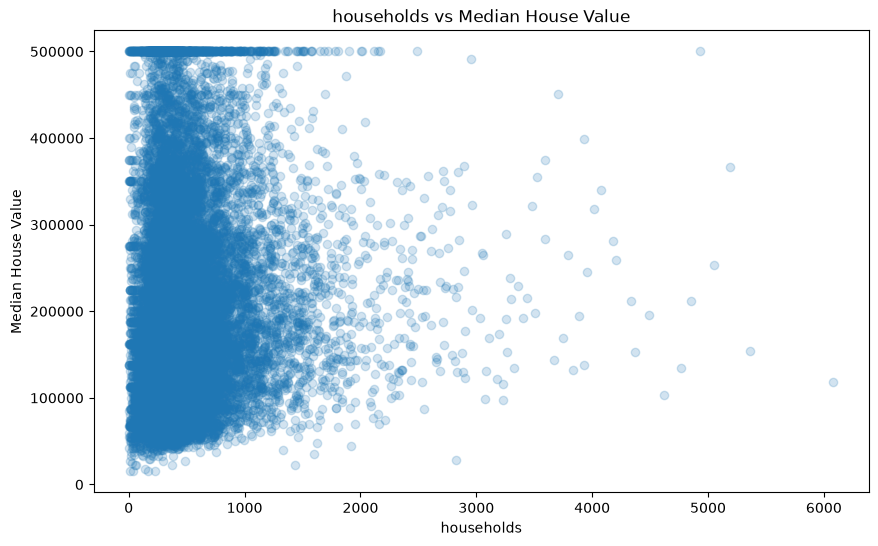

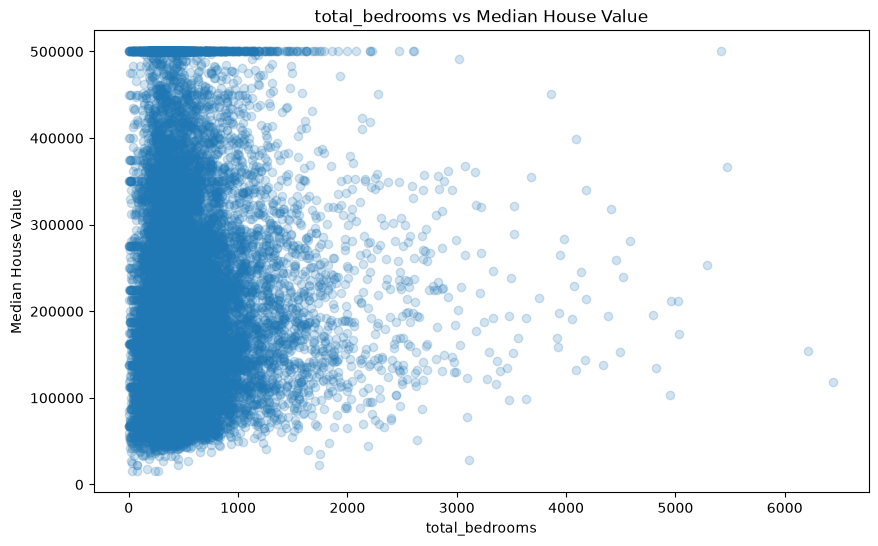

In [89]:
features_to_investigate = [
    "latitude",
    "longitude",
    "population",
    "households",
    "total_bedrooms"
]

for i in features_to_investigate:
    plt.figure(figsize=(10,6))

    plt.scatter(df[i], df["median_house_value"], alpha=0.2)
    plt.xlabel(i)
    plt.ylabel("Median House Value")
    plt.title(f"{i} vs Median House Value")

    plt.show()

## Key Findings: Feature-Target Relationships

The deeper visual analysis reveals several important patterns that are not
fully captured by Pearson correlation.

1. `median_income` shows the strongest relationship with
   `median_house_value`. The relationship is positive but not perfectly
   linear, with the increase in house value becoming steeper at higher
   income levels.

2. `housing_median_age` shows a weak relationship with house value, with
   substantial variation in house values across nearly all age levels.

3. `total_rooms`, `total_bedrooms`, `population`, and `households` show
   substantial dispersion and right-skewed distributions. Their absolute
   values do not show strong linear relationships with house value.

4. `latitude` and `longitude` have weak Pearson correlations with the
   target, but their scatter plots reveal clear structured patterns.
   This suggests that geographic variables may contain nonlinear spatial
   information that Pearson correlation does not capture.

5. Several size-related variables contain extreme observations and are
   strongly correlated with one another. This suggests potential
   redundancy that should be investigated during feature selection.

6. A substantial concentration of observations occurs at the upper
   boundary of the target variable, which may affect regression models
   and should be considered when interpreting model performance.

# 3. Geographic Analysis

The previous analysis showed that `latitude` and `longitude` have relatively
weak Pearson correlations with `median_house_value`. However, their
individual scatter plots revealed clear patterns across geographic
locations.

Therefore, correlation alone may not adequately capture the relationship
between geographic location and housing prices.

This section investigates the spatial distribution of the observations and
examines whether housing prices and median income vary systematically across
geographic regions.

The main questions are:

1. Is there a clear geographic pattern in housing prices?

2. Are high-value and low-value housing observations concentrated in
   particular geographic regions?

3. Does `median_income` vary geographically?

4. Do geographic patterns remain visible when considering income and
   housing value together?

5. Does geographic information appear to contain information that may not
   be captured by `median_income` alone?

## 3.1 Geographic Distribution

We first visualize the geographic distribution of the observations using
latitude and longitude. This provides a spatial overview of the dataset
before examining housing prices.

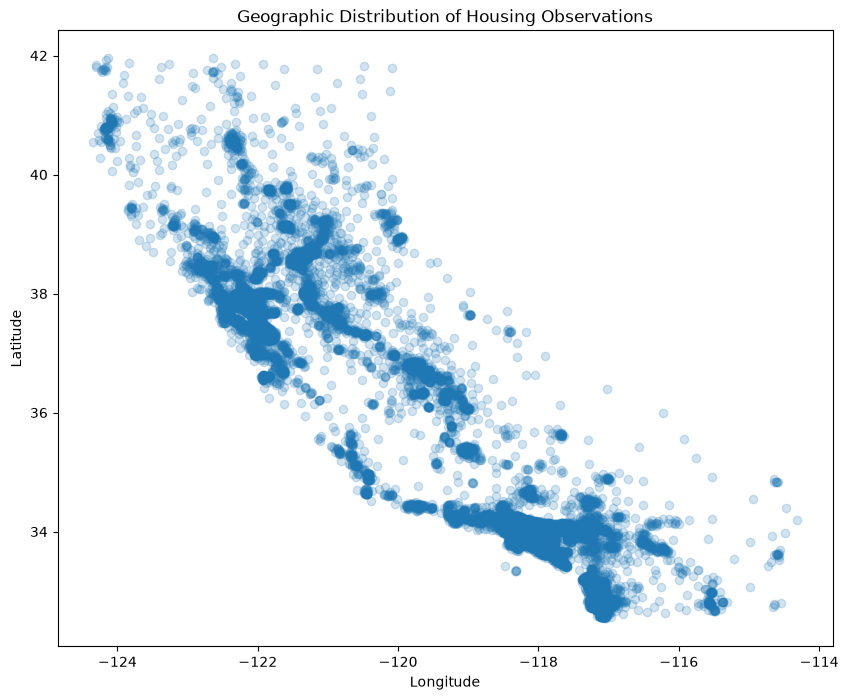

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(df["longitude"], df["latitude"], alpha=0.2)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Housing Observations")

plt.show() #The Graph Demonstrates the approximate shape of california


### Observation

The observations are not uniformly distributed across geographic space.
Some regions contain substantially higher concentrations of observations
than others.

### Interpretation

The dataset represents different geographic regions with varying numbers
of observations. Therefore, geographic patterns in subsequent plots should
be interpreted in the context of this uneven spatial distribution.

### 3.2 Geographic Distribution of Median House Value

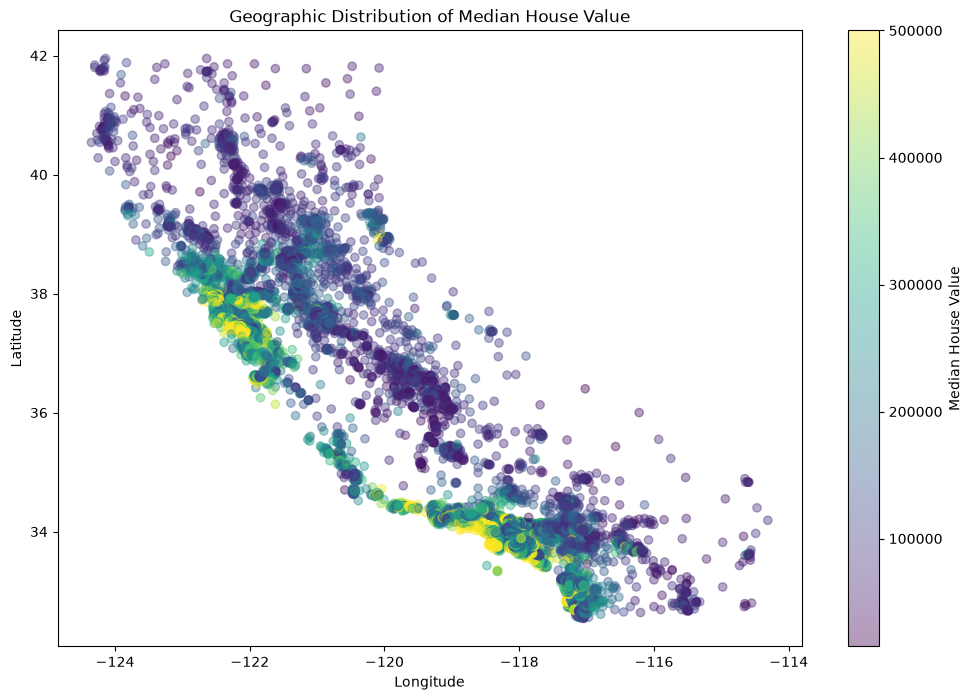

In [ ]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    alpha=0.4
)

plt.colorbar(scatter, label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Median House Value")

plt.show() 

'''The Graph helps us to understand the regions 
   where are the expensive and inexpensive houses are located'''

### Observation

Median house values are not uniformly distributed across geographic
space. Higher value observations appear concentrated in particular
geographic regions, while other regions contain predominantly lower value
observations.

### Interpretation

This indicates a strong spatial association between geographic location
and housing value. Howeverwe cannot finally conclude that
geographic location causes differences in house prices.

### Research Implication

The spatial structure suggests that latitude and longitude may contain
predictive information that is not captured by their individual Pearson
correlations with the target.

### 3.3 Geographic Distribution of Median Income

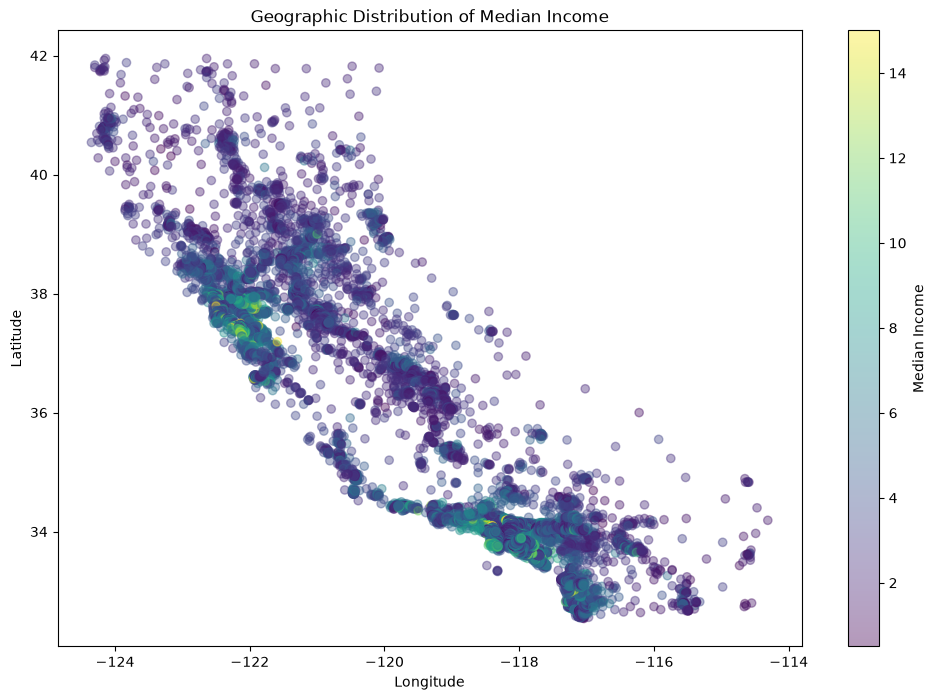

In [92]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_income"],
    cmap="viridis",
    alpha=0.4
)

plt.colorbar(scatter, label="Median Income")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Median Income")

plt.show()

### 3.3 Joint Analysis of both Median house Value and Median Income with geographic Location

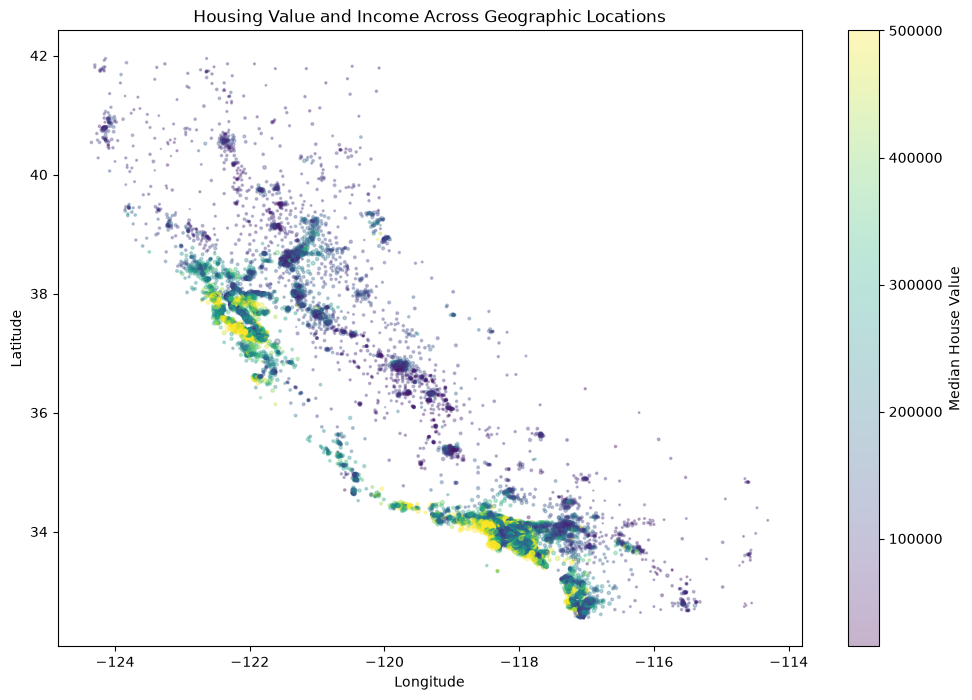

In [ ]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['median_house_value'],
    s=df['median_income'],
    alpha=0.3
    )

plt.colorbar(scatter, label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Housing Value and Income Across Geographic Locations")

plt.show() #This Graph demonstrates the house median value depends on the location beyond income

### Observation

The joint visualizatin shows that regions with higher median income
often coincide with regions containing higher median house values.
However the relationship is not uniform across geographic space.

### Interpretation

The spatial distribution suggests that housing value may be influenced
by a combination of both median income and geographic factors.

### Research Implication

This motivates a later modeling experiment comparing models with and
without geographic variables to determine whether latitude and longitude
provide additional predictive value beyond the other features.

### 4. Outlier Analysis


Box Plot of each numerical features

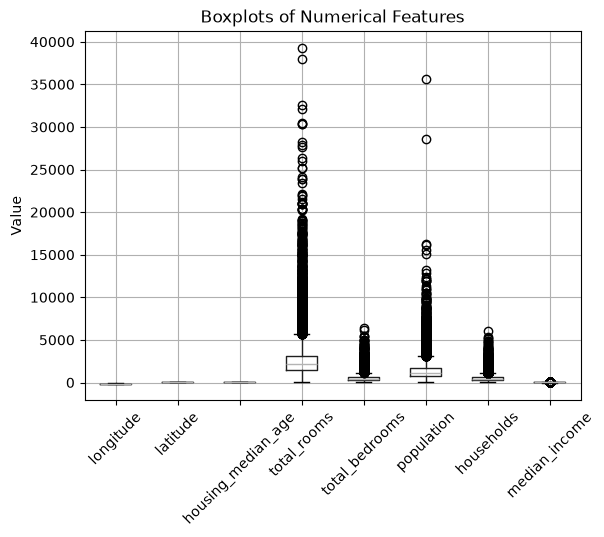

In [98]:
df[numerical_features].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")

plt.show()

### 4.1 Investigate each feature separately


C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


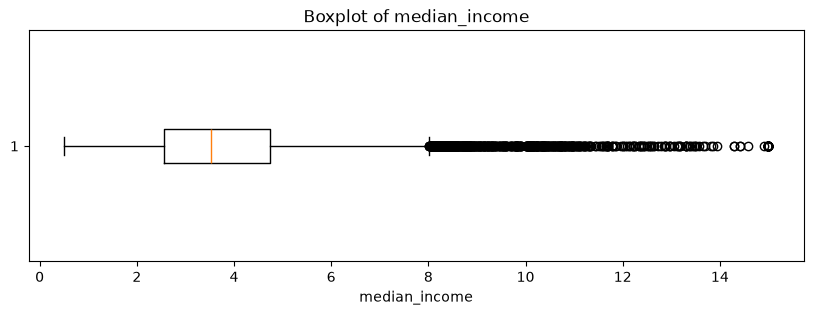

C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


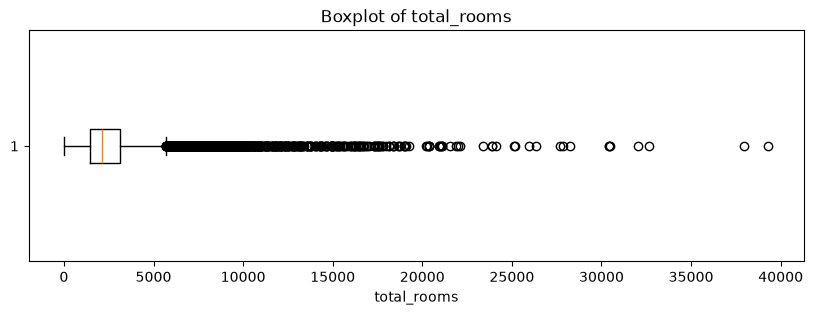

C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


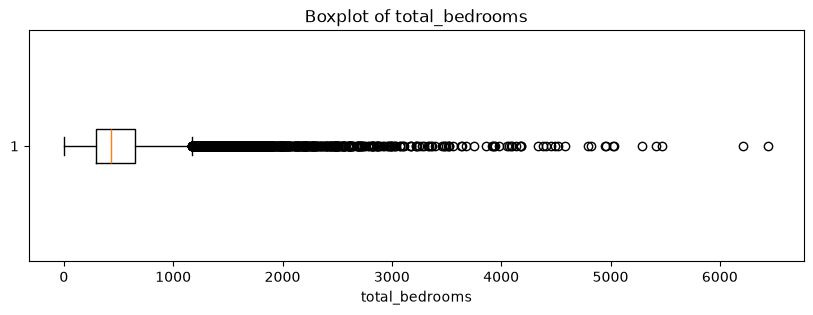

C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


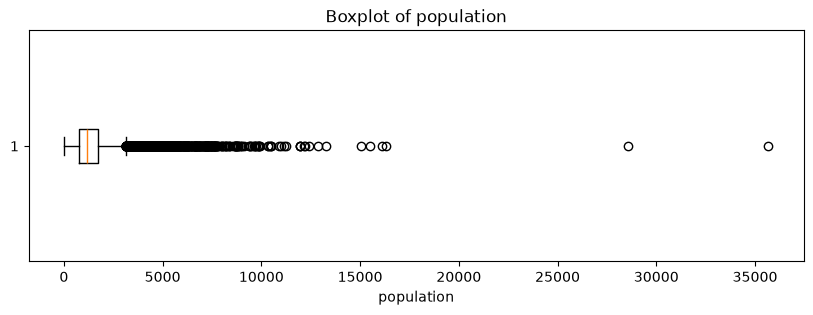

C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


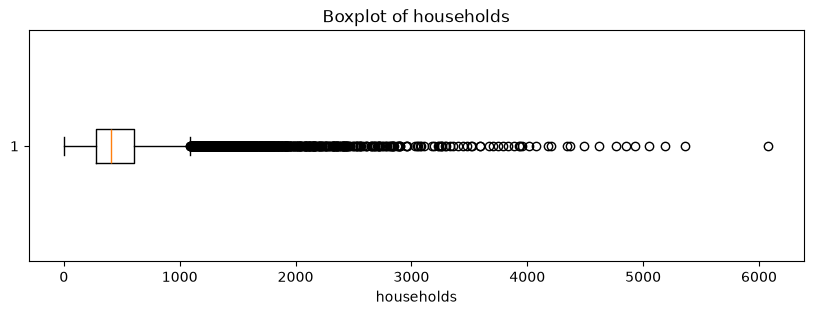

C:\Users\HP\AppData\Local\Temp\ipykernel_6804\433900452.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature].dropna(), vert=False)


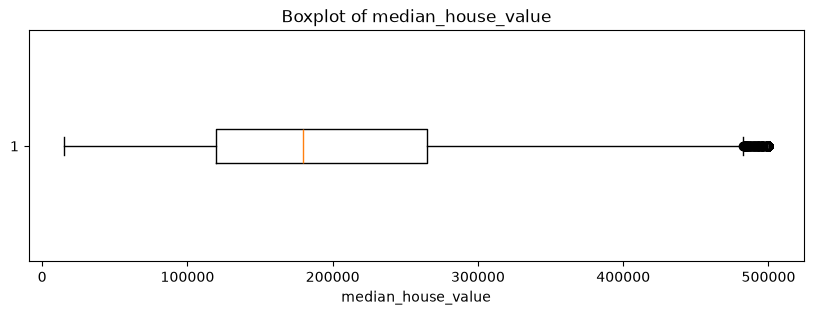

In [99]:
features_to_check = [
    "median_income",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_house_value"
]

for feature in features_to_check:

    plt.figure(figsize=(10, 3))

    plt.boxplot(df[feature].dropna(), vert=False)

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.show()

### 4.2 Quantify the extremes

In [ ]:
def outlier_summary(data, features):
    results = []

    for feature in features:
        series = data[feature].dropna()

        #Calculate the 25th (Q1) and 75th (Q3) percentiles
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        #Calculate the Interquartile Range
        IQR = Q3 - Q1

        #Define boundaries (1.5 times the IQR)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter and count Oultliers
        outliers = series[
            (series < lower_bound) |
            (series > upper_bound)
        ]

        #appending Results in a dictionary
        results.append({
            "feature": feature,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": len(outliers),
            "outlier_percentage": len(outliers) / len(series) * 100
        })

    return pd.DataFrame(results)


In [101]:
outlier_results = outlier_summary(df, features_to_check)

outlier_results

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,median_income,2.5634,4.74325,2.17985,-0.706375,8.013025,681,3.299419
1,total_rooms,1447.7500,3148.00000,1700.25000,-1102.625000,5698.375000,1287,6.235465
2,total_bedrooms,296.0000,647.00000,351.00000,-230.500000,1173.500000,1271,6.220330
3,population,787.0000,1725.00000,938.00000,-620.000000,3132.000000,1196,5.794574
4,households,280.0000,605.00000,325.00000,-207.500000,1092.500000,1220,5.910853
5,median_house_value,119600.0000,264725.00000,145125.00000,-98087.500000,482412.500000,1071,5.188953


## Outlier Analysis: Key Findings
The analysis identified extreme observations across several numerical
features, particularly variables describing neighborhood size such as
`median_income`,`total_rooms`, `total_bedrooms`, `population`, and `households`.

The IQR method identifies these observations as statistical outliers,
but their classification does not imply that they are erroneous. Many
extreme values may represent legitimate large or densely populated
neighborhoods.

The target variable also exhibits a pronounced upper boundary around
$500,000. This pattern should be treated as a characteristic of the
target distribution rather than simply removing these observations as
outliers.

Because regression models can be sensitive to extreme observations,
outlier sensitivity may be investigated as a separate modeling experiment.

### Interpretation
This suggests that the target variable has an upper cap rather than
simply containing a small number of naturally occurring extreme values.

### Research Implication
The upper bound effect may limit the ability of regression models to
distinguish between observations whose true values could potentially
exceed the observed maximum. This should be considered when interpreting
model predictions and evaluation metrics.

### 5. EDA Findings and Research Hypotheses

## 6.1 Key EDA Findings

### 1. Median Income

`median_income` has the strongest Pearson correlation with
`median_house_value` (r ≈ 0.688). The relationship is strongly positive,
but the scatter and binned analysis suggest that it is not perfectly
linear. The increase in mean house value becomes steeper at higher
income levels.

### 2. Nonlinear Relationships

Several feature-target relationships do not appear to follow a simple
linear pattern. This suggests that a purely linear model may not capture
all of the structure present in the data.

### 3. Geographic Structure

`latitude` and `longitude` have weak individual Pearson correlations
with `median_house_value`, but their geographic visualizations reveal
clear spatial patterns in housing prices.

This suggests that geographic information may contain predictive
information that is not captured by individual linear correlations.

### 4. Feature Redundancy

Several housingsize variables show very strong correlations with each
other. In particular, `total_rooms`, `total_bedrooms`, `population`, and
`households` appear to contain overlapping information.

This raises the possibility that some predictors may be redundant.

### 5. Extreme Observations

The univariate analysis identified extreme observations in several
numerical variables. These observations have been retained because
statistical extremeness does not necessarily imply that an observation
is invalid.

Their potential influence on regression models can be investigated
during the experimental stage.

### 6. Missing Values

`total_bedrooms` contains a total 207 missing observations.

The missing values will therefore be handled during preprocessing rather
than removing the corresponding observations.

## 6.2 Research Hypotheses

Based on the findings from exploratory data analysis, the following
hypotheses will be investigated during the experimental stage.

### H1: Effect of Training Data Size

Increasing the amount of training data will improve out-of-sample
performance, although the improvement is expected to diminish as the
amount of available training data increases.

### H2: Effect of Feature Information

Increasing the number of informative features will improve predictive
performance, while adding weakly informative or redundant features may
provide diminishing returns.

### H3: Feature Selection and Redundancy

Removing highly redundant predictors may reduce model complexity while
preserving or improving out-of-sample predictive performance.

### H4: Geographic Information

Adding `latitude` and `longitude` may improve out-of-sample prediction
because the EDA revealed spatial patterns in housing prices that are not
captured by their individual Pearson correlations with the target.

### H5: Feature Scaling and Optimization

Feature scaling will improve the convergence behavior of Gradient
Descent when predictor variables have substantially different scales.

### H6: Model Complexity and Generalization

Increasing model complexity will initially improve predictive performance,
but excessive complexity may lead to overfitting and poorer performance
on unseen data.

### H7: Regularization

Regularization will reduce the influence of model complexity and may
improve generalization, particularly when correlated or redundant
predictors are present.

### H8: Sensitivity to Extreme Observations

Extreme observations may have a measurable influence on regression model
parameters and predictive performance.

## 6.3 Experimental Roadmap

The experiments are designed to investigate how different aspects of the
data, preprocessing, and model design affect regression performance and
generalization.

| Hypothesis / Question | Experiment | Main Evaluation |
|---|---|---|
| **H1: Baseline Performance** | Establish a baseline using Linear Regression with the initial feature set | RMSE, MAE, R² |
| **H2: Training Data Size** | Evaluate model performance using different proportions of the training data | Validation RMSE, MAE, R² |
| **H3: Number of Features** | Evaluate how predictive performance changes as the number of input features increases | Validation RMSE, MAE, R² |
| **H4: Feature Selection** | Compare the full feature set with reduced/selected feature sets | Validation RMSE, MAE, R² |
| **H5: Geographic Information** | Compare models with and without `latitude` and `longitude` | Validation RMSE, MAE, R² |
| **H6: Feature Scaling** | Compare Gradient Descent with and without feature scaling | Convergence speed, loss, validation performance |
| **H7: Model Complexity** | Compare models with increasing levels of complexity | Training vs validation performance |
| **H8: Regularization** | Compare unregularized and regularized regression models using different regularization strengths | Validation RMSE, MAE, R² |
| **H9: Outlier Sensitivity** | Compare model performance with different approaches to handling extreme observations | Validation RMSE, MAE, R² |

## 6.4 Evaluation and Experimental Strategy

The project will evaluate models primarily based on their ability to
generalize to previously unseen data.

The dataset will be divided into a development set and a held-out test
set. The development set will be used for model training, validation,
feature selection, and experimental comparisons, while the test set will
be reserved for final evaluation.

The experiments will investigate how different factors affect model
performance, including:

- Training dataset size
- Number and selection of input features
- Feature scaling
- Geographic features
- Model complexity
- Regularization
- Potential sensitivity to extreme observations

Model performance will be evaluated using:

- **RMSE:** Measures the typical prediction error while giving greater
  weight to larger errors.
- **MAE:** Measures the average absolute prediction error and is easier
  to interpret in the original target units.
- **R²:** Measures the proportion of variance in the target explained by
  the model.

Training and validation performance will also be compared where
appropriate to investigate overfitting and underfitting.

For experiments involving multiple model or preprocessing choices,
cross-validation on the development set will be used where appropriate.
The held-out test set will be used only for final evaluation.